# Exemplo 08 - LLMs: atenção e Transformers, do zero ao ChatGPT

### Palestra Machine Learning e IA: Da máquina que aprende à IA que age

### Prof. Dr. Ahirton Lopes (https://github.com/ahirtonlopes)

**Onde isso aparece no mercado:** ChatGPT, Gemini e praticamente todo LLM atual, além de tradutores automáticos e buscadores, são construídos sobre a arquitetura Transformer.

**Conceito da palestra:** Atenção permite que cada palavra "olhe" para todas as outras da frase e decida quais importam mais: é a peça central dos Transformers.

---

> *"Attention is All You Need"*  
> Vaswani et al., Google Brain (2017), um dos artigos mais citados da história da IA

---

## Roteiro do notebook:

| Seção | Conteúdo |
|-------|----------|
| 1️⃣ | O problema das RNNs e LSTMs |
| 2️⃣ | Intuição: o que é Atenção? |
| 3️⃣ | Query, Key e Value - a biblioteca do saber |
| 4️⃣ | Self-Attention passo a passo |
| 5️⃣ | Visualizando Attention Maps |
| 6️⃣ | Multi-Head Attention |
| 7️⃣ | Positional Encoding |
| 8️⃣ | Arquitetura completa do Transformer |
| 9️⃣ | Inferência com Transformers pré-treinados |
| 🔟 | Do Transformer ao ChatGPT/Gemini |
| 🎯 | Exercícios e discussão |

---
## 1️⃣ O Problema das Arquiteturas Clássicas

### Como RNNs/LSTMs processam texto:

```
Frase: "O gato que eu comprei ontem fugiu hoje"

RNN processa palavra por palavra, esquerda para direita:

"O" → h₁ → "gato" → h₂ → "que" → h₃ → ... → "fugiu" → h₈ → "hoje" → h₉
                                                                          ↑
                                              Para prever "hoje", h₉ precisa
                                              lembrar de "gato" que está
                                              8 palavras atrás!
```

### Problemas fundamentais:

| Problema | Descrição | Impacto |
|----------|-----------|--------|
| **Vanishing Gradient** | Gradiente some em sequências longas | Modelo esquece início da frase |
| **Sequencial** | Não paralelizável | Treinamento muito lento |
| **Memória limitada** | Estado oculto tem tamanho fixo | Comprime tudo em um vetor |
| **Dependências longas** | Difícil aprender relações distantes | Péssimo em documentos longos |

```
❌ LSTM (melhor que RNN, mas ainda com limitações):

   [O] → [gato] → [que] → [eu] → [comprei] → [ontem] → [fugiu] → [hoje]
    ────────────────────────────────────────────────────────────────────►
    Sequential bottleneck: não dá para processar em paralelo!
    
✅ TRANSFORMER (solução):
   Todas as palavras se comunicam DIRETAMENTE umas com as outras!
   Processamento totalmente paralelo = muito mais rápido!
```


---
## 2️⃣ Intuição: o que é Atenção?

### A analogia da reunião de negócios

Imagine que você está em uma reunião e alguém faz uma pergunta:

> *"Qual é a estratégia para o próximo trimestre?"*

Você não presta igual atenção a TODAS as pessoas na sala.  
Você **foca** nas pessoas mais relevantes para aquela pergunta:
- 👔 CFO: muito relevante (fala sobre números)
- 📊 VP de Estratégia: muito relevante
- 🎨 Designer: menos relevante neste momento
- ☕ Assistente: pouco relevante para esta pergunta

**Isso é exatamente o que a Atenção faz com palavras:**

```
Frase: "O banco estava cheio de dinheiro"

Ao processar "dinheiro", o modelo presta MAIS atenção em:
  • "banco" ← muito relevante! (contexto financeiro, não ribeirinho)
  • "cheio"  ← relevante (quantidade)
  • "estava" ← pouco relevante
  • "O"      ← irrelevante

Graças à atenção, o modelo entende que "banco" = instituição financeira!
```


In [1]:
# Instalação
# No Colab estas bibliotecas já vêm instaladas; a linha abaixo só garante que estejam presentes.
!pip install tensorflow transformers torch matplotlib seaborn numpy -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

print(f'TensorFlow: {tf.__version__}')
print('✅ Bibliotecas carregadas!')

TensorFlow: 2.21.0
✅ Bibliotecas carregadas!


---
## 3️⃣ Query, Key e Value - A Biblioteca do Saber

### A analogia do sistema de busca

Pense em como você pesquisa um livro em uma biblioteca:

```
🔍 QUERY (Consulta) = sua pergunta
   "Quero saber sobre redes neurais"

🏷️  KEY (Chave) = título/etiqueta de cada livro
   Livro 1: "Deep Learning"  
   Livro 2: "Cálculo"       
   Livro 3: "Python"        
   Livro 4: "Neurociência"  

📚 VALUE (Valor) = conteúdo real do livro
   (o que você realmente lê quando pega o livro)

RELEVÂNCIA (Attention Score) = quão bem sua Query combina com cada Key
   Deep Learning  ████████████ 0.85 (muito relevante!)
   Cálculo        ████░░░░░░░░ 0.40 (um pouco)
   Python         ██████░░░░░░ 0.55 (moderado)
   Neurociência   ██░░░░░░░░░░ 0.20 (pouco relevante)

OUTPUT = soma ponderada dos Values pela relevância
   = 0.85 × (conteúdo Deep Learning)
   + 0.40 × (conteúdo Cálculo)
   + 0.55 × (conteúdo Python)
   + 0.20 × (conteúdo Neurociência)
```

### Fórmula matemática:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Onde:
- **Q** = Query matrix
- **K** = Key matrix  
- **V** = Value matrix
- **√d_k** = fator de escala (evita gradientes muito pequenos)


In [3]:
# Implementando Self-Attention do zero, passo a passo

def scaled_dot_product_attention(Q, K, V, mask=None, verbose=True):
    """
    Implementação manual do mecanismo de atenção

    Args:
        Q: Query  (seq_len, d_k)
        K: Key    (seq_len, d_k)
        V: Value  (seq_len, d_v)
    Returns:
        output: representação contextualizada
        attention_weights: matriz de atenção para visualização
    """
    d_k = Q.shape[-1]  # dimensão das keys

    # PASSO 1: Calcular scores Q × K^T
    scores = np.matmul(Q, K.T)  # (seq_len, seq_len)
    if verbose:
        print(f'Passo 1 - Scores brutos Q×Kᵀ:\n{scores.round(3)}\n')

    # PASSO 2: Escalar para evitar gradientes muito pequenos
    scores = scores / np.sqrt(d_k)
    if verbose:
        print(f'Passo 2 - Scores escalonados (÷√{d_k}):\n{scores.round(3)}\n')

    # PASSO 3: Softmax → pesos de atenção somam 1
    # softmax(x_i) = exp(x_i) / sum(exp(x_j))
    exp_scores = np.exp(scores - scores.max(axis=-1, keepdims=True))  # estabilidade numérica
    attention_weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)
    if verbose:
        print(f'Passo 3 - Pesos de atenção (após Softmax):\n{attention_weights.round(3)}')
        print(f'          (cada linha soma 1.0: {attention_weights.sum(axis=-1).round(3)})\n')

    # PASSO 4: Soma ponderada dos Values
    output = np.matmul(attention_weights, V)
    if verbose:
        print(f'Passo 4 - Output (soma ponderada de V):\n{output.round(3)}')

    return output, attention_weights


# Exemplo concreto com frase simples
# Tokens: ["Gato", "come", "peixe", "fresco"]
# Embeddings simplificados (4 tokens × 4 dimensões)
np.random.seed(42)
seq_len = 4
d_model = 4

# Simulando embeddings dos tokens
X = np.random.randn(seq_len, d_model)
tokens = ['Gato', 'come', 'peixe', 'fresco']

# Em Self-Attention, Q=K=V são projeções lineares de X
# Para simplificar, usamos X diretamente
Q = X.copy()
K = X.copy()
V = X.copy()

print('🔍 Calculando Self-Attention para: "Gato come peixe fresco"')
print('=' * 60)
output, attn_weights = scaled_dot_product_attention(Q, K, V)

🔍 Calculando Self-Attention para: "Gato come peixe fresco"
Passo 1 - Scores brutos Q×Kᵀ:
[[ 3.005  2.108 -1.318 -1.589]
 [ 2.108  3.193 -1.106 -2.764]
 [-1.318 -1.106  0.946 -0.09 ]
 [-1.589 -2.764 -0.09   7.011]]

Passo 2 - Scores escalonados (÷√4):
[[ 1.502  1.054 -0.659 -0.794]
 [ 1.054  1.596 -0.553 -1.382]
 [-0.659 -0.553  0.473 -0.045]
 [-0.794 -1.382 -0.045  3.505]]

Passo 3 - Pesos de atenção (após Softmax):
[[0.539 0.344 0.062 0.054]
 [0.332 0.572 0.067 0.029]
 [0.142 0.157 0.439 0.262]
 [0.013 0.007 0.027 0.953]]
          (cada linha soma 1.0: [1. 1. 1. 1.])

Passo 4 - Output (soma ponderada de V):
[[ 0.171 -0.225  0.771  1.026]
 [ 0.007 -0.199  1.037  0.898]
 [-0.109 -0.319 -0.315 -0.015]
 [ 0.222 -1.811 -1.636 -0.523]]


---
## 4️⃣ Self-Attention - Cada Palavra Olha para Todas

Na **Self-Attention**, Q, K e V são todos derivados da **mesma sequência**.  
Cada token aprende a atentar para os outros tokens mais relevantes.

```
"O  banco  estava  cheio  de  dinheiro"
 ↑    ↑      ↑       ↑    ↑     ↑

Ao representar 'banco', o modelo combina informação de TODOS os tokens,
com pesos aprendidos:

banco_final = 0.05×O + 0.40×banco + 0.05×estava + 0.10×cheio + 0.05×de + 0.35×dinheiro
                                                                              ↑
                              Alta atenção em 'dinheiro' resolve a ambiguidade!
```


---
## 5️⃣ Visualizando Attention Maps


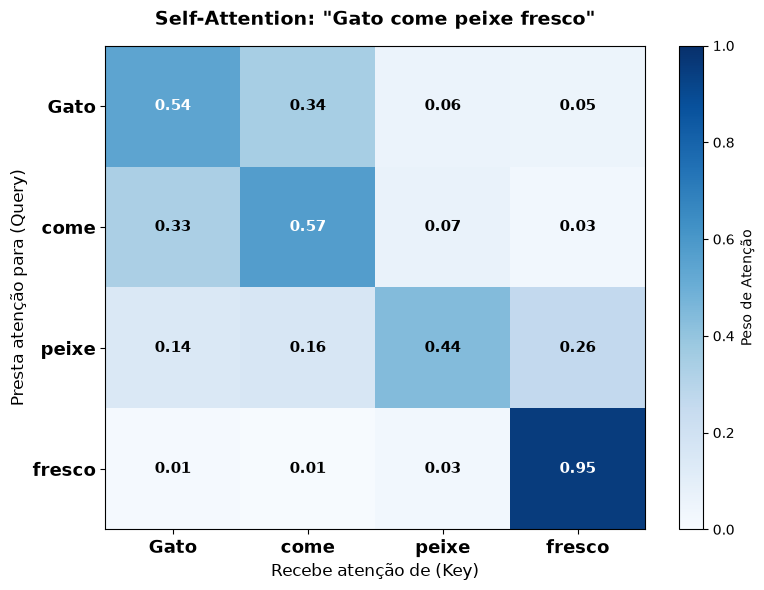


📌 Como ler o mapa:
  • Linha = qual token está "olhando" (Query)
  • Coluna = para qual token ele olha (Key)
  • Valor = intensidade da atenção (0=ignora, 1=foco total)
  • Diagonal = atenção da palavra para ela mesma


In [4]:
def plot_attention_map(attention_weights, tokens, title='Attention Map', figsize=(8, 6)):
    """
    Visualiza a matriz de atenção como heatmap
    Linha = token que PRESTA atenção (Query)
    Coluna = token que RECEBE atenção (Key)
    """
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(attention_weights, cmap='Blues', aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, fontsize=13, fontweight='bold')
    ax.set_yticklabels(tokens, fontsize=13, fontweight='bold')
    ax.set_xlabel('Recebe atenção de (Key)', fontsize=12)
    ax.set_ylabel('Presta atenção para (Query)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

    # Adiciona valores nas células
    for i in range(len(tokens)):
        for j in range(len(tokens)):
            val = attention_weights[i, j]
            color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=11, color=color, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Peso de Atenção')
    plt.tight_layout()
    plt.show()


# Visualizando a atenção calculada
plot_attention_map(attn_weights, tokens,
                  title='Self-Attention: "Gato come peixe fresco"')

print('\n📌 Como ler o mapa:')
print('  • Linha = qual token está "olhando" (Query)')
print('  • Coluna = para qual token ele olha (Key)')
print('  • Valor = intensidade da atenção (0=ignora, 1=foco total)')
print('  • Diagonal = atenção da palavra para ela mesma')

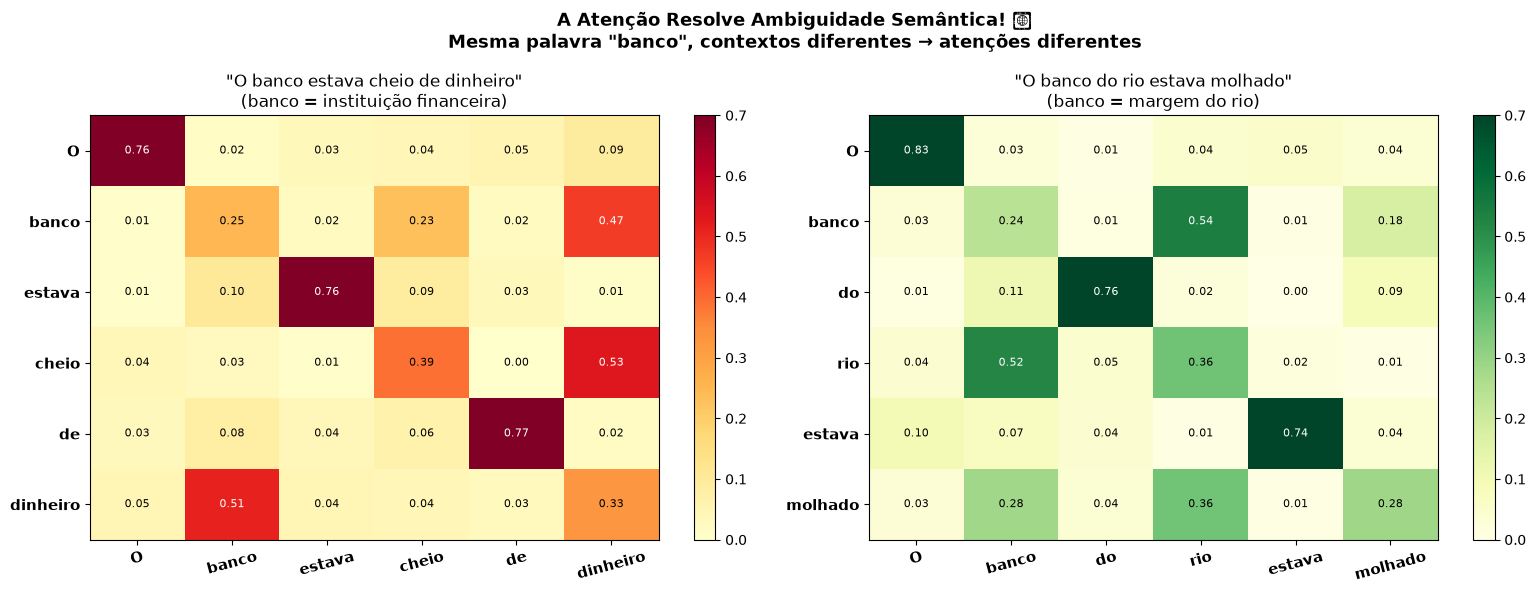

💡 Nas duas frases, a palavra "banco" aparece.
   Na esquerda: presta atenção em "dinheiro" → banco financeiro
   Na direita: presta atenção em "rio" → margem do rio
   Isso é o poder da representação contextual!


In [5]:
# Exemplo semântico mais rico: simulando atenção aprendida
# Comparando frases com ambiguidade

def create_semantic_attention(tokens, focus_pairs):
    """
    Cria uma matriz de atenção semântica para fins didáticos
    focus_pairs: lista de (query_idx, key_idx, peso) para relações semânticas
    """
    n = len(tokens)
    # Começa com atenção base (diagonal + ruído pequeno)
    attn = np.eye(n) * 0.3 + np.random.rand(n, n) * 0.05

    for q_idx, k_idx, weight in focus_pairs:
        attn[q_idx, k_idx] += weight

    # Normaliza cada linha (softmax simulado)
    attn = attn / attn.sum(axis=1, keepdims=True)
    return attn


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Exemplo 1: Banco financeiro
tokens1 = ['O', 'banco', 'estava', 'cheio', 'de', 'dinheiro']
# banco presta muita atenção em dinheiro
attn1 = create_semantic_attention(tokens1,
    [(1, 5, 0.6), (1, 3, 0.3), (3, 5, 0.4), (5, 1, 0.5)])

im1 = axes[0].imshow(attn1, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.7)
axes[0].set_xticks(range(len(tokens1)))
axes[0].set_yticks(range(len(tokens1)))
axes[0].set_xticklabels(tokens1, fontsize=11, fontweight='bold', rotation=15)
axes[0].set_yticklabels(tokens1, fontsize=11, fontweight='bold')
axes[0].set_title('"O banco estava cheio de dinheiro"\n(banco = instituição financeira)', fontsize=12)
for i in range(len(tokens1)):
    for j in range(len(tokens1)):
        val = attn1[i, j]
        col = 'white' if val > 0.4 else 'black'
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=col)
plt.colorbar(im1, ax=axes[0])

# Exemplo 2: Banco de rio
tokens2 = ['O', 'banco', 'do', 'rio', 'estava', 'molhado']
# banco presta muita atenção em rio
attn2 = create_semantic_attention(tokens2,
    [(1, 3, 0.7), (1, 5, 0.2), (3, 1, 0.4), (5, 1, 0.3), (5, 3, 0.4)])

im2 = axes[1].imshow(attn2, cmap='YlGn', aspect='auto', vmin=0, vmax=0.7)
axes[1].set_xticks(range(len(tokens2)))
axes[1].set_yticks(range(len(tokens2)))
axes[1].set_xticklabels(tokens2, fontsize=11, fontweight='bold', rotation=15)
axes[1].set_yticklabels(tokens2, fontsize=11, fontweight='bold')
axes[1].set_title('"O banco do rio estava molhado"\n(banco = margem do rio)', fontsize=12)
for i in range(len(tokens2)):
    for j in range(len(tokens2)):
        val = attn2[i, j]
        col = 'white' if val > 0.4 else 'black'
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=col)
plt.colorbar(im2, ax=axes[1])

fig.suptitle('A Atenção Resolve Ambiguidade Semântica! 🎯\nMesma palavra "banco", contextos diferentes → atenções diferentes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Nas duas frases, a palavra "banco" aparece.')
print('   Na esquerda: presta atenção em "dinheiro" → banco financeiro')
print('   Na direita: presta atenção em "rio" → margem do rio')
print('   Isso é o poder da representação contextual!')

---
## 6️⃣ Multi-Head Attention

Uma única cabeça de atenção olha para **um tipo** de relação.  
Mas linguagem tem múltiplos tipos de relações!

```
Frase: "João que é engenheiro construiu a ponte"

Head 1 - Relações sintáticas:
  construiu → João (quem construiu?)
  construiu → ponte (o que construiu?)

Head 2 - Referências pronominais:
  que → João ("que" se refere a João)

Head 3 - Relações semânticas:
  engenheiro → construiu (profissão implica ação)
  engenheiro → ponte (engenheiro constrói pontes)

Head 4 - Posição/estrutura:
  atenção local (palavras adjacentes)

→ Concatena os 4 outputs → representação muito mais rica!
```

```
MULTI-HEAD ATTENTION:

Input X ──┬──► W_Q1, W_K1, W_V1 ──► Head₁ ──┐
          ├──► W_Q2, W_K2, W_V2 ──► Head₂ ──┤
          ├──► W_Q3, W_K3, W_V3 ──► Head₃ ──┤──► Concat ──► W_O ──► Output
          └──► W_Q4, W_K4, W_V4 ──► Head₄ ──┘
          
Cada head aprende relações DIFERENTES de forma independente!
```


In [6]:
class MultiHeadAttention(layers.Layer):
    """
    Multi-Head Attention implementado do zero com Keras
    Permite que o modelo preste atenção em múltiplos aspectos simultaneamente
    """

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model deve ser divisível por num_heads'

        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads  # dimensão por head

        # Projeções lineares para Q, K, V e output
        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)
        self.dense = layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        """Divide d_model em num_heads subespaces"""
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])  # (batch, heads, seq, depth)

    def call(self, v, k, q, mask=None):
        batch_size = tf.shape(q)[0]

        # Projeções lineares
        q = self.wq(q)  # (batch, seq, d_model)
        k = self.wk(k)
        v = self.wv(v)

        # Divide em múltiplas cabeças
        q = self.split_heads(q, batch_size)  # (batch, heads, seq, depth)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Atenção scaled dot-product para cada head
        # (batch, heads, seq, depth)
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled = matmul_qk / tf.math.sqrt(dk)

        if mask is not None:
            scaled += (mask * -1e9)

        attention_weights = tf.nn.softmax(scaled, axis=-1)
        output = tf.matmul(attention_weights, v)  # (batch, heads, seq, depth)

        # Reagrupa as cabeças
        output = tf.transpose(output, perm=[0, 2, 1, 3])  # (batch, seq, heads, depth)
        output = tf.reshape(output, (batch_size, -1, self.d_model))  # (batch, seq, d_model)

        return self.dense(output), attention_weights


# Teste
mha = MultiHeadAttention(d_model=128, num_heads=8)
x_test = tf.random.normal((2, 10, 128))  # batch=2, seq=10, d_model=128
out, weights = mha(x_test, x_test, x_test)
print(f'✅ Multi-Head Attention funcionando!')
print(f'   Input:  {x_test.shape}  →  (batch, seq_len, d_model)')
print(f'   Output: {out.shape}  →  (batch, seq_len, d_model)')
print(f'   Weights: {weights.shape}  →  (batch, num_heads, seq_len, seq_len)')

✅ Multi-Head Attention funcionando!
   Input:  (2, 10, 128)  →  (batch, seq_len, d_model)
   Output: (2, 10, 128)  →  (batch, seq_len, d_model)
   Weights: (2, 8, 10, 10)  →  (batch, num_heads, seq_len, seq_len)


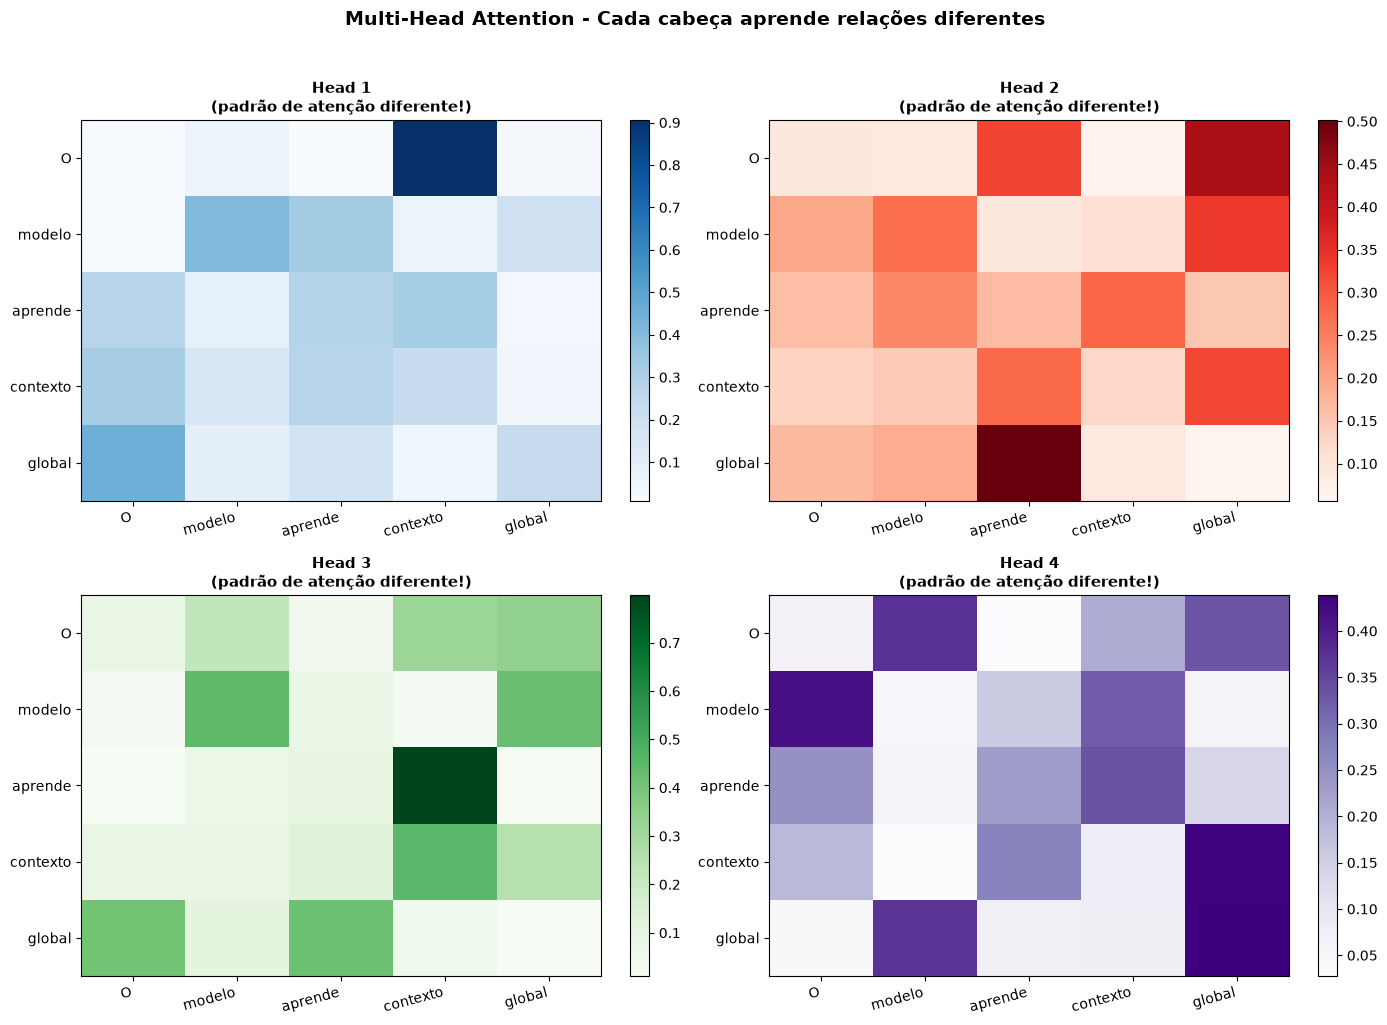

In [7]:
# Visualizando múltiplas cabeças de atenção
def visualize_multi_heads(attention_weights, tokens, num_heads_to_show=4, title_prefix='Head'):
    """
    Mostra os attention maps de diferentes cabeças
    attention_weights: (num_heads, seq_len, seq_len)
    """
    cols = 2
    rows = (num_heads_to_show + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    axes = axes.flatten()

    cmaps = ['Blues', 'Reds', 'Greens', 'Purples', 'Oranges', 'YlOrBr']

    for head_idx in range(min(num_heads_to_show, attention_weights.shape[0])):
        attn = attention_weights[head_idx].numpy()
        ax = axes[head_idx]

        im = ax.imshow(attn, cmap=cmaps[head_idx % len(cmaps)], aspect='auto')
        ax.set_xticks(range(len(tokens)))
        ax.set_yticks(range(len(tokens)))
        ax.set_xticklabels(tokens, fontsize=10, rotation=15, ha='right')
        ax.set_yticklabels(tokens, fontsize=10)
        ax.set_title(f'{title_prefix} {head_idx + 1}\n(padrão de atenção diferente!)',
                     fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle('Multi-Head Attention - Cada cabeça aprende relações diferentes',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Gera atenção multi-head para uma frase de exemplo
sentence_tokens = ['O', 'modelo', 'aprende', 'contexto', 'global']
n_tokens = len(sentence_tokens)

mha_viz = MultiHeadAttention(d_model=64, num_heads=4)
x_viz = tf.random.normal((1, n_tokens, 64))
_, weights_viz = mha_viz(x_viz, x_viz, x_viz)

# weights_viz: (1, 4, n_tokens, n_tokens)
visualize_multi_heads(weights_viz[0], sentence_tokens, num_heads_to_show=4)

---
## 7️⃣ Positional Encoding - Ensinando Ordem ao Transformer

A Self-Attention é **invariante à posição** - sem ajuda, ela vê os tokens como um conjunto não ordenado!

```
"O gato comeu o rato"  ==  "rato o comeu gato O"  (para a atenção pura)

Precisamos injetar informação de POSIÇÃO!
```

**Solução**: adicionar um vetor especial a cada token que codifica sua posição.

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

**Por que senos e cossenos?**
- Frequências diferentes → cada posição tem um "fingerprint" único
- O modelo pode aprender a relação entre posições por diferença de fase
- Generaliza para sequências mais longas que as vistas no treino


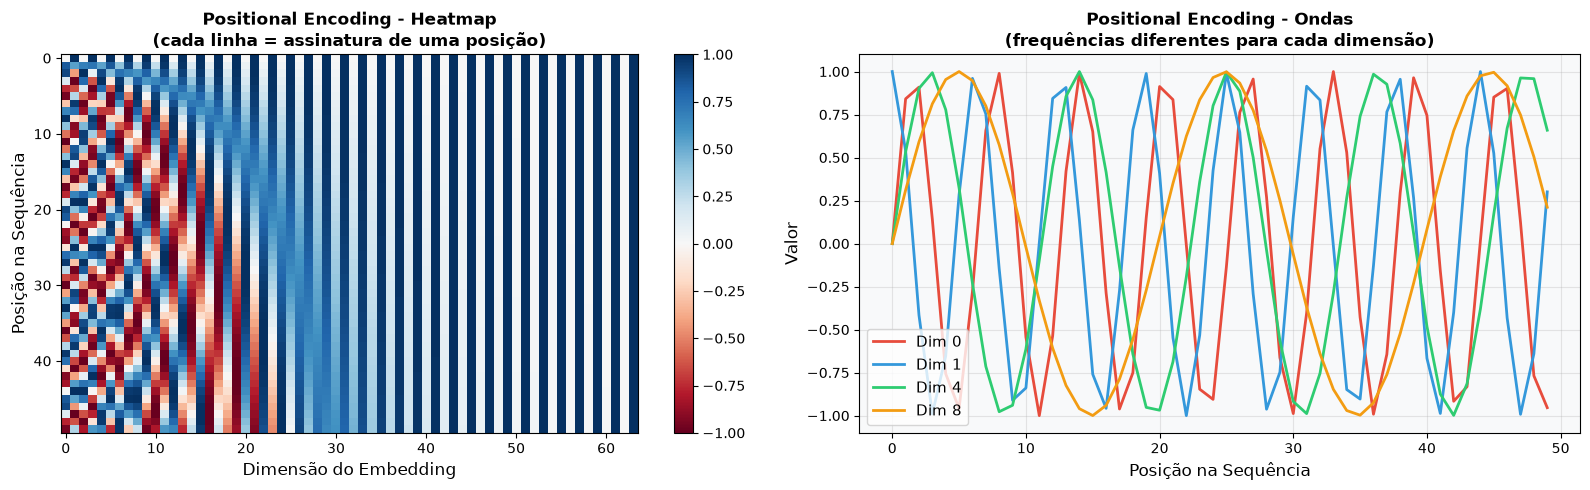

💡 Cada posição tem uma combinação ÚNICA de senos e cossenos!
   Posição próximas têm encodings similares (continuidade)
   O modelo aprende a usar essa informação automaticamente


In [8]:
def positional_encoding(max_len, d_model):
    """
    Gera vetores de Positional Encoding
    Cada posição recebe um vetor único de 'assinatura'
    """
    PE = np.zeros((max_len, d_model))
    positions = np.arange(max_len)[:, np.newaxis]       # (max_len, 1)
    dims = np.arange(d_model)[np.newaxis, :]             # (1, d_model)

    # Frequências diferentes para dimensões pares/ímpares
    freqs = 1 / np.power(10000, (2 * (dims // 2)) / d_model)
    angles = positions * freqs

    PE[:, 0::2] = np.sin(angles[:, 0::2])  # dimensões pares: seno
    PE[:, 1::2] = np.cos(angles[:, 1::2])  # dimensões ímpares: cosseno

    return PE


# Gerando e visualizando o Positional Encoding
MAX_SEQ_LEN = 50
D_MODEL = 64
PE = positional_encoding(MAX_SEQ_LEN, D_MODEL)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap do PE completo
im = axes[0].imshow(PE, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xlabel('Dimensão do Embedding', fontsize=12)
axes[0].set_ylabel('Posição na Sequência', fontsize=12)
axes[0].set_title('Positional Encoding - Heatmap\n(cada linha = assinatura de uma posição)',
                  fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[0])

# Primeiras dimensões ao longo das posições
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i, dim in enumerate([0, 1, 4, 8]):
    axes[1].plot(PE[:, dim], label=f'Dim {dim}', color=colors[i], linewidth=2)

axes[1].set_xlabel('Posição na Sequência', fontsize=12)
axes[1].set_ylabel('Valor', fontsize=12)
axes[1].set_title('Positional Encoding - Ondas\n(frequências diferentes para cada dimensão)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print('💡 Cada posição tem uma combinação ÚNICA de senos e cossenos!')
print('   Posição próximas têm encodings similares (continuidade)')
print('   O modelo aprende a usar essa informação automaticamente')

---
## 8️⃣ Arquitetura Completa do Transformer

```
         ENCODER                              DECODER
    ┌─────────────────┐               ┌─────────────────────┐
    │                 │               │                     │
    │  Input Embedding│               │  Output Embedding   │
    │  + Pos. Encoding│               │  + Pos. Encoding    │
    │        ↓        │               │        ↓            │
    │  ┌───────────┐  │               │  ┌───────────────┐  │
    │  │Multi-Head │  │               │  │Masked Multi-  │  │
    │  │Attention  │  │               │  │Head Attention │  │
    │  └─────┬─────┘  │               │  └──────┬────────┘  │
    │    Add & Norm   │               │     Add & Norm       │
    │        ↓        │               │         ↓            │
    │  ┌───────────┐  │   Context     │  ┌───────────────┐  │
    │  │Feed-Fwd   │  │──────────────►│  │Cross-Attention│  │
    │  │Network    │  │               │  │(Q de Decoder, │  │
    │  └─────┬─────┘  │               │  │ K,V de Encoder│  │
    │    Add & Norm   │               │  └──────┬────────┘  │
    │        ↓        │               │     Add & Norm       │
    │   (×N layers)   │               │         ↓            │
    └─────────────────┘               │  ┌───────────────┐  │
                                      │  │Feed-Forward   │  │
                                      │  └──────┬────────┘  │
                                      │     Add & Norm       │
                                      │    (×N layers)       │
                                      │         ↓            │
                                      │  Linear + Softmax    │
                                      │   (próximo token)    │
                                      └─────────────────────┘
```

### GPT-family: só usa o Decoder!
ChatGPT, GPT-4, Claude - são modelos **decoder-only**:  
preveem o próximo token com base em todos os anteriores.


In [9]:
class TransformerBlock(layers.Layer):
    """
    Um bloco do Transformer (como os que se empilham no GPT/BERT)
    Componentes:
      1. Multi-Head Self-Attention
      2. Add & Norm (residual connection + layer normalization)
      3. Feed-Forward Network
      4. Add & Norm
    """

    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        # Multi-Head Attention
        self.mha = MultiHeadAttention(d_model, num_heads)

        # Feed-Forward: dois Dense com ReLU no meio
        # Expansão para 4× d_model - padrão do Transformer original
        self.ffn = keras.Sequential([
            layers.Dense(dff, activation='relu'),
            layers.Dense(d_model)
        ])

        # Layer Normalization (diferente de BatchNorm - normaliza por token)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        # 1. Multi-Head Self-Attention + Residual
        attn_out, _ = self.mha(x, x, x, mask=mask)
        attn_out = self.dropout1(attn_out, training=training)
        out1 = self.layernorm1(x + attn_out)  # Add & Norm

        # 2. Feed-Forward + Residual
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out, training=training)
        out2 = self.layernorm2(out1 + ffn_out)  # Add & Norm

        return out2


# Teste do bloco
block = TransformerBlock(d_model=128, num_heads=8, dff=512)
x_test = tf.random.normal((2, 20, 128))  # batch=2, seq=20, d=128
out_test = block(x_test)
print(f'✅ Transformer Block funcionando!')
print(f'   Input:  {x_test.shape}')
print(f'   Output: {out_test.shape}  (mesma shape - pode empilhar N blocos!)')

✅ Transformer Block funcionando!
   Input:  (2, 20, 128)
   Output: (2, 20, 128)  (mesma shape - pode empilhar N blocos!)


In [10]:
# Mini Transformer para classificação de texto
# Demonstra como montar o modelo completo

class MiniTransformerClassifier(keras.Model):
    """
    Transformer simples para classificação de texto
    Arquitetura tipo BERT (encoder-only)
    """

    def __init__(self, vocab_size, max_len, d_model, num_heads, dff, num_classes, num_blocks=2):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        # Embedding de tokens
        self.embedding = layers.Embedding(vocab_size, d_model)

        # Positional Encoding (como parâmetro aprendível - mais simples)
        self.pos_embedding = layers.Embedding(max_len, d_model)

        # Blocos Transformer empilhados
        self.transformer_blocks = [
            TransformerBlock(d_model, num_heads, dff)
            for _ in range(num_blocks)
        ]

        # Classificador
        self.pooling = layers.GlobalAveragePooling1D()
        self.dropout = layers.Dropout(0.1)
        self.classifier = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)

        # Token embedding + Positional encoding
        x = self.embedding(x) + self.pos_embedding(positions)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))  # escala padrão

        # Passa pelos blocos Transformer
        for block in self.transformer_blocks:
            x = block(x, training=training)

        # Pooling global e classificação
        x = self.pooling(x)
        x = self.dropout(x, training=training)
        return self.classifier(x)


# Instanciando o modelo
model = MiniTransformerClassifier(
    vocab_size=10000,
    max_len=128,
    d_model=64,
    num_heads=4,
    dff=256,
    num_classes=2,  # positivo/negativo
    num_blocks=2
)

# Teste com input aleatório
x_dummy = tf.random.uniform((4, 128), minval=0, maxval=10000, dtype=tf.int32)
out_dummy = model(x_dummy)
print(f'✅ Mini Transformer Classifier!')
print(f'   Input:  {x_dummy.shape}  (batch=4, seq_len=128)')
print(f'   Output: {out_dummy.shape}  (probabilidades para 2 classes)')

model.summary()

✅ Mini Transformer Classifier!
   Input:  (4, 128)  (batch=4, seq_len=128)
   Output: (4, 2)  (probabilidades para 2 classes)


Model: "mini_transformer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (4, 128, 64)           │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (128, 64)              │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ ?                      │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ ?                      │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (4, 2)                 │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 748,290 (2.85 MB)

 Trainable params: 748,290 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

---
## 9️⃣ Inferência com Transformers Pré-Treinados

Na prática, **não treinamos Transformers do zero** - usamos modelos pré-treinados.  
O HuggingFace `transformers` dá acesso a centenas de modelos em uma linha!


In [11]:
from transformers import pipeline, AutoTokenizer, AutoModel
import torch

print('🤗 HuggingFace Transformers - Modelos Pré-Treinados')
print('=' * 55)

# 1. Análise de Sentimento
print('\n1️⃣  Análise de Sentimento:')
sentiment = pipeline('sentiment-analysis',
                     model='nlptown/bert-base-multilingual-uncased-sentiment')

frases = [
    "Esse produto é incrível! Superou todas as minhas expectativas.",
    "Péssima experiência, não recomendo de forma alguma.",
    "O atendimento foi razoável, mas a entrega demorou."
]

for frase in frases:
    result = sentiment(frase)[0]
    stars = int(result['label'][0])
    bar = '⭐' * stars + '☆' * (5 - stars)
    print(f'   "{frase[:50]}..."')
    print(f'   → {bar} ({result["label"]}, confiança: {result["score"]:.2%})\n')

🤗 HuggingFace Transformers - Modelos Pré-Treinados

1️⃣  Análise de Sentimento:


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

   "Esse produto é incrível! Superou todas as minhas e..."
   → ⭐⭐⭐⭐⭐ (5 stars, confiança: 90.72%)

   "Péssima experiência, não recomendo de forma alguma..."
   → ⭐☆☆☆☆ (1 star, confiança: 90.32%)

   "O atendimento foi razoável, mas a entrega demorou...."
   → ⭐⭐⭐☆☆ (3 stars, confiança: 41.50%)



In [12]:
# 2. Reconhecimento de Entidades (NER)
print('2️⃣  Reconhecimento de Entidades (NER):')
# Modelo multilíngue treinado para NER (pessoas, organizações e locais)
ner = pipeline('ner', model='Davlan/bert-base-multilingual-cased-ner-hrl',
               aggregation_strategy='simple')

texto = "A Microsoft anunciou que Satya Nadella apresentou novos produtos em Seattle."
print(f'   Texto: "{texto}"')

ner_result = ner(texto)
for ent in ner_result:
    print(f'   → "{ent["word"]}" = {ent["entity_group"]} (confiança: {ent["score"]:.2%})')

print()

# 3. Question Answering
print('3️⃣  Question Answering (Q&A):')
# Nas versões novas da biblioteca (transformers 5.x) o atalho pipeline('question-answering')
# foi removido. Fazemos o mesmo passo a passo "na mão": o modelo aponta onde, dentro do texto,
# a resposta começa e termina, e recortamos esse trecho.
from transformers import AutoModelForQuestionAnswering

qa_tokenizer = AutoTokenizer.from_pretrained('deepset/roberta-base-squad2')
qa_model = AutoModelForQuestionAnswering.from_pretrained('deepset/roberta-base-squad2')
qa_model.eval()

def qa(question, context, max_tokens_resposta=30):
    enc = qa_tokenizer(question, context, return_tensors='pt', truncation=True)
    with torch.no_grad():
        out = qa_model(**enc)
    # só vale apontar para tokens do contexto (sequence_id == 1), não da pergunta
    fora_do_contexto = torch.tensor([sid != 1 for sid in enc.sequence_ids(0)])
    p_inicio = out.start_logits[0].masked_fill(fora_do_contexto, -1e9).softmax(-1)
    p_fim = out.end_logits[0].masked_fill(fora_do_contexto, -1e9).softmax(-1)
    # probabilidade de cada par (início, fim), com fim >= início e resposta curta
    pares = torch.tril(torch.triu(p_inicio[:, None] * p_fim[None, :]), diagonal=max_tokens_resposta)
    i, j = divmod(int(pares.argmax()), pares.shape[1])
    resposta = qa_tokenizer.decode(enc['input_ids'][0][i:j + 1]).strip()
    return {'answer': ' '.join(resposta.split()), 'score': float(pares[i, j])}

context = """
The Transformer architecture was introduced in the paper 'Attention is All You Need'
by Vaswani et al. in 2017, while working at Google Brain. The paper showed that
attention mechanisms alone could replace recurrent networks and achieve state-of-the-art
results in machine translation tasks.
"""

questions = [
    "When was the Transformer architecture introduced?",
    "Who introduced the Transformer?",
    "What did the paper show?"
]

for q in questions:
    answer = qa(question=q, context=context)
    print(f'   Q: {q}')
    print(f'   A: "{answer["answer"]}" (confiança: {answer["score"]:.2%})\n')

2️⃣  Reconhecimento de Entidades (NER):


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   Texto: "A Microsoft anunciou que Satya Nadella apresentou novos produtos em Seattle."
   → "Microsoft" = ORG (confiança: 99.97%)
   → "Satya Nadella" = PER (confiança: 97.25%)
   → "Seattle" = LOC (confiança: 99.97%)

3️⃣  Question Answering (Q&A):


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   Q: When was the Transformer architecture introduced?
   A: "2017" (confiança: 97.75%)

   Q: Who introduced the Transformer?
   A: "Vaswani et al." (confiança: 72.43%)

   Q: What did the paper show?
   A: "that attention mechanisms alone could replace recurrent networks and achieve state-of-the-art results in machine translation tasks" (confiança: 19.12%)



🔬 Extraindo Attention Maps de um BERT pré-treinado...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Frase: "The cat sat on the mat"
   Tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]']
   Camadas de atenção: 12
   Shape por camada: torch.Size([1, 12, 8, 8])  (batch, heads, seq, seq)


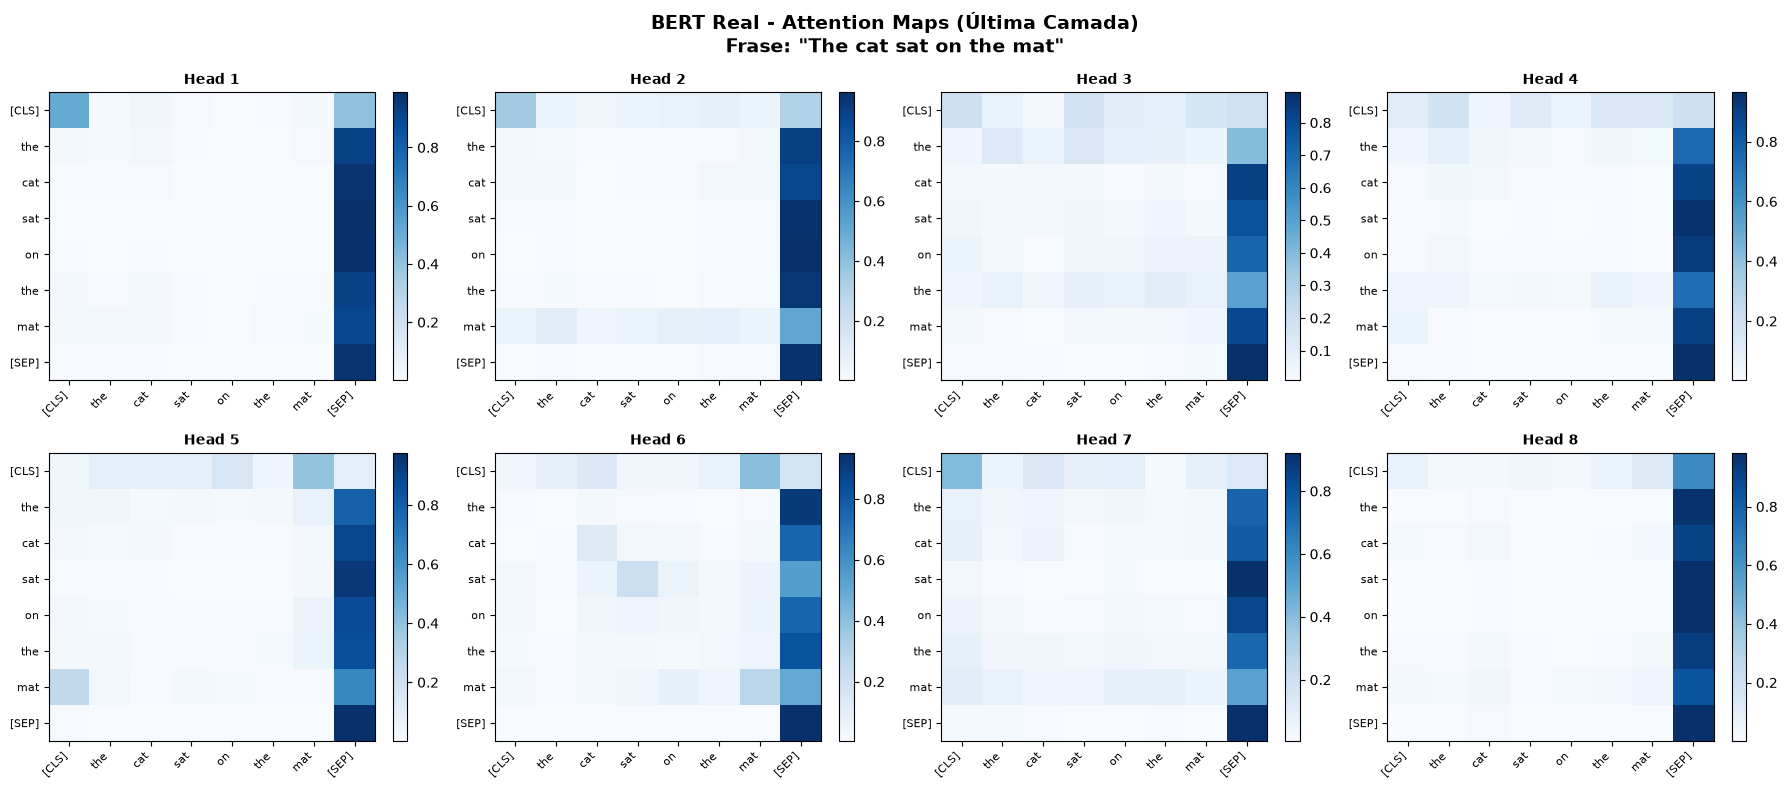

💡 Cada head captura padrões diferentes!
   Algumas heads focam em tokens adjacentes (atenção local)
   Outras capturam relações de longa distância (sujeito-verbo, etc.)


In [13]:
# Extraindo e visualizando attention weights de um BERT real
from transformers import BertTokenizer, BertModel
import torch

print('🔬 Extraindo Attention Maps de um BERT pré-treinado...')

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
model_bert.eval()

# Frase de exemplo
sentence = "The cat sat on the mat"
inputs = tokenizer(sentence, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = model_bert(**inputs)

# outputs.attentions: tupla de (batch, heads, seq, seq) por camada
attentions = outputs.attentions  # 12 camadas, 12 heads cada

print(f'   Frase: "{sentence}"')
print(f'   Tokens: {tokens}')
print(f'   Camadas de atenção: {len(attentions)}')
print(f'   Shape por camada: {attentions[0].shape}  (batch, heads, seq, seq)')

# Visualiza última camada, primeiras 4 heads
last_layer_attn = attentions[-1][0].detach().numpy()  # (heads, seq, seq)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(f'BERT Real - Attention Maps (Última Camada)\nFrase: "{sentence}"',
             fontsize=14, fontweight='bold')

for head_idx, ax in enumerate(axes.flatten()):
    attn = last_layer_attn[head_idx]
    im = ax.imshow(attn, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f'Head {head_idx + 1}', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

print('💡 Cada head captura padrões diferentes!')
print('   Algumas heads focam em tokens adjacentes (atenção local)')
print('   Outras capturam relações de longa distância (sujeito-verbo, etc.)')

---
## 🔟 Do Transformer ao ChatGPT e Gemini

### A linha do tempo da revolução:

```
2017 ──► Transformer (Vaswani et al.)
          "Attention is All You Need"
          
2018 ──► BERT (Google) - Encoder bidirectional
          Melhor modelo de NLP até então
          
2018 ──► GPT-1 (OpenAI) - Decoder autoregressive
          117M parâmetros
          
2019 ──► GPT-2 (OpenAI) - Tão poderoso que não foi lançado completo
          1.5B parâmetros
          
2020 ──► GPT-3 (OpenAI)
          175B parâmetros - few-shot learning emergente!
          
2021 ──► Codex, GitHub Copilot
          GPT para código
          
2022 ──► InstructGPT + RLHF (Reinforcement Learning from Human Feedback)
         ChatGPT lançado → 100M usuários em 2 meses
         
2023 ──► GPT-4, Claude 2, Gemini Pro
          Multimodalidade, raciocínio avançado
          
2024 ──► Claude 3, GPT-4o, Gemini 1.5, Llama 3
          Contexto longo (1M tokens), tempo real, agentic AI
          
2025 ──► Claude 4, GPT-5
          Raciocínio avançado, agentes autônomos
```

### Por que Transformers dominam tudo?

| Aplicação | Modelo | Uso |
|-----------|--------|-----|
| **NLP** | BERT, GPT, Claude | Geração, análise, tradução |
| **Visão** | ViT, CLIP, Flamingo | Classificação, geração de imagens |
| **Multimodal** | GPT-4V, Gemini, Claude | Texto + imagem + áudio |
| **Código** | Codex, CodeLlama | GitHub Copilot, Cursor |
| **Proteínas** | AlphaFold 2 | Dobramento de proteínas |
| **Áudio** | Whisper, AudioLM | Transcrição, geração de música |
| **Vídeo** | Sora, Lumiere | Geração de vídeo |
| **Agentes** | AutoGPT, Claude Agents | Automação de tarefas |


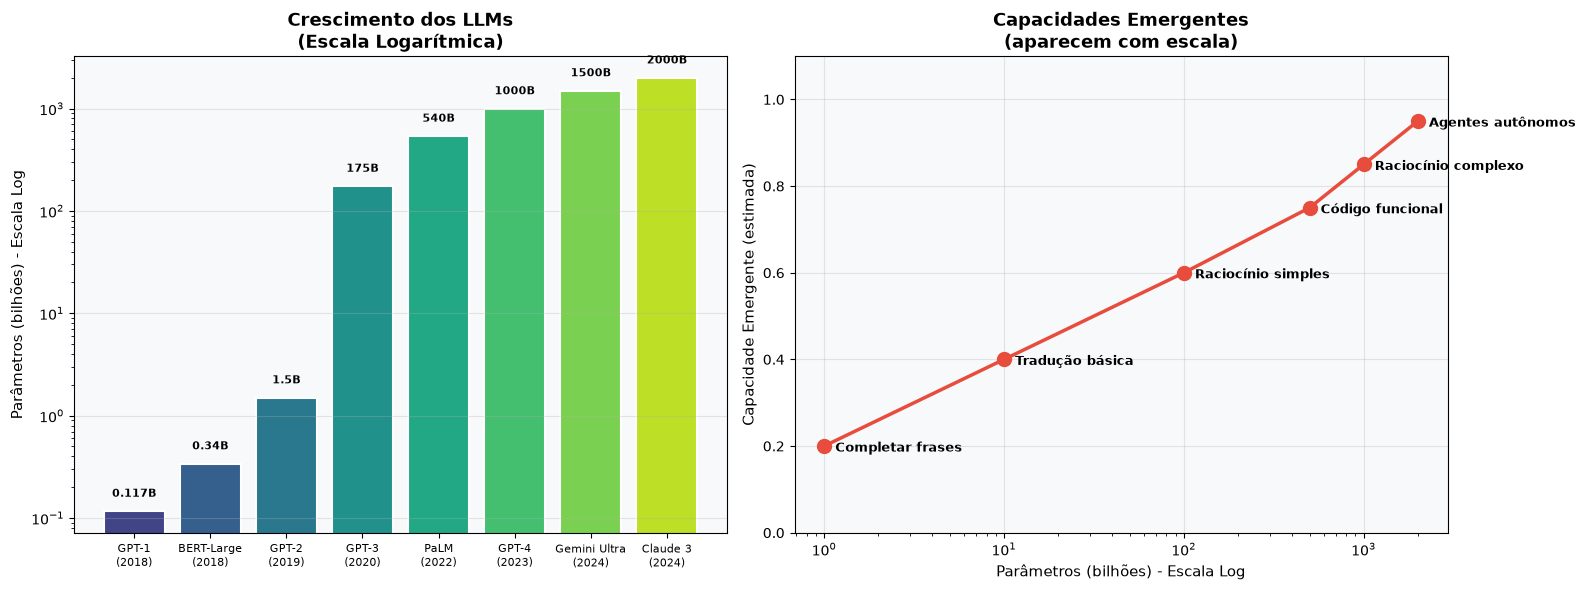

⚡ Capacidades emergentes: comportamentos que surgem espontaneamente
   com escala suficiente, sem programação explícita!
   Ex: GPT-3 aprendeu a fazer aritmética sem treino específico


In [14]:
# Visualização: Escala dos LLMs ao longo do tempo
modelos = {
    'GPT-1\n(2018)': 0.117,
    'BERT-Large\n(2018)': 0.34,
    'GPT-2\n(2019)': 1.5,
    'GPT-3\n(2020)': 175,
    'PaLM\n(2022)': 540,
    'GPT-4\n(2023)': 1000,  # estimativa
    'Gemini Ultra\n(2024)': 1500,  # estimativa
    'Claude 3\n(2024)': 2000,  # estimativa
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras (escala log)
names = list(modelos.keys())
params = list(modelos.values())
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.9, len(names)))

bars = ax1.bar(names, params, color=colors_bar, edgecolor='white', linewidth=1.5)
ax1.set_yscale('log')
ax1.set_ylabel('Parâmetros (bilhões) - Escala Log', fontsize=11)
ax1.set_title('Crescimento dos LLMs\n(Escala Logarítmica)', fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', labelsize=8)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_facecolor('#f8f9fa')

for bar, val in zip(bars, params):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
             f'{val}B', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Capacidades emergentes vs parâmetros
emergent = [
    (1, 0.2, 'Completar frases'),
    (10, 0.4, 'Tradução básica'),
    (100, 0.6, 'Raciocínio simples'),
    (500, 0.75, 'Código funcional'),
    (1000, 0.85, 'Raciocínio complexo'),
    (2000, 0.95, 'Agentes autônomos'),
]

params_e = [e[0] for e in emergent]
capac = [e[1] for e in emergent]
labels_e = [e[2] for e in emergent]

ax2.plot(params_e, capac, 'o-', color='#e74c3c', linewidth=2.5, markersize=10)
for x, y, label in emergent:
    ax2.annotate(label, (x, y), textcoords='offset points', xytext=(8, -4),
                fontsize=9, fontweight='bold')

ax2.set_xscale('log')
ax2.set_xlabel('Parâmetros (bilhões) - Escala Log', fontsize=11)
ax2.set_ylabel('Capacidade Emergente (estimada)', fontsize=11)
ax2.set_title('Capacidades Emergentes\n(aparecem com escala)', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print('⚡ Capacidades emergentes: comportamentos que surgem espontaneamente')
print('   com escala suficiente, sem programação explícita!')
print('   Ex: GPT-3 aprendeu a fazer aritmética sem treino específico')

---
## 🎯 Exercícios, Atividades e Discussão

### 💬 Perguntas para discussão:

1. **Estratégia**: Sua empresa tem 500K documentos internos. Como você usaria Transformers para criar um sistema de busca inteligente? Quais riscos?

2. **Negócios**: O que é o fenômeno de **hallucination** em LLMs? Como isso impacta aplicações críticas (medicina, jurídico, finanças)?

3. **Técnica**: Por que modelos como GPT processam tokens (pedaços de palavras) e não palavras inteiras? Quais as vantagens?

4. **Futuro**: Transformers dominaram NLP, Visão, Áudio, Código... Quais áreas ainda resistem? Por quê?

5. **Ética**: Modelos de linguagem absorvem vieses dos dados de treino. Como empresas deveriam auditar isso?

---

### 🛠️ Atividades práticas:

#### Nível 1 - Exploração:
```python
# Use o pipeline do HuggingFace para:
# a) Analisar sentimento de reviews de produtos da sua empresa
# b) Extrair entidades de artigos de notícias
# c) Fazer perguntas sobre documentos internos
```

#### Nível 2 - Fine-tuning:
```python
# Fine-tune um BERT em dataset do seu domínio:
# - Classificação de e-mails de suporte
# - Detecção de cláusulas em contratos
# - Categorização de produtos em e-commerce
```

#### Nível 3 - RAG (Retrieval Augmented Generation):
```python
# Combine um LLM com busca vetorial:
# 1. Embeddings dos documentos → armazenar em FAISS/ChromaDB
# 2. Query do usuário → buscar documentos relevantes
# 3. Contexto + LLM → resposta fundamentada nos seus docs
# (sem hallucination nos dados proprietários!)
```

### 📚 Mini-projetos sugeridos:

| Projeto | Tecnologia | Impacto |
|---------|-----------|--------|
| Chat com documentos PDF | LangChain + Claude/GPT | Análise de contratos |
| Classificador de NPS | BERT fine-tuned | Customer Success |
| Sumarizador de reuniões | Whisper + GPT | Produtividade |
| Extrator de dados de NF-e | NER + Regex | Automação fiscal |
| Gerador de copy de marketing | GPT + Few-shot | Marketing |

### 🔗 Próximos passos para aprofundamento:

- **Papers**: "Attention is All You Need", "BERT", "GPT-3", "InstructGPT"
- **Cursos**: Stanford CS224N, Fast.ai Practical NLP
- **Plataformas**: HuggingFace, LangChain, LlamaIndex
- **Modelos open-source**: Llama 3, Mistral, Gemma
- **Fine-tuning acessível**: LoRA, QLoRA, Unsloth


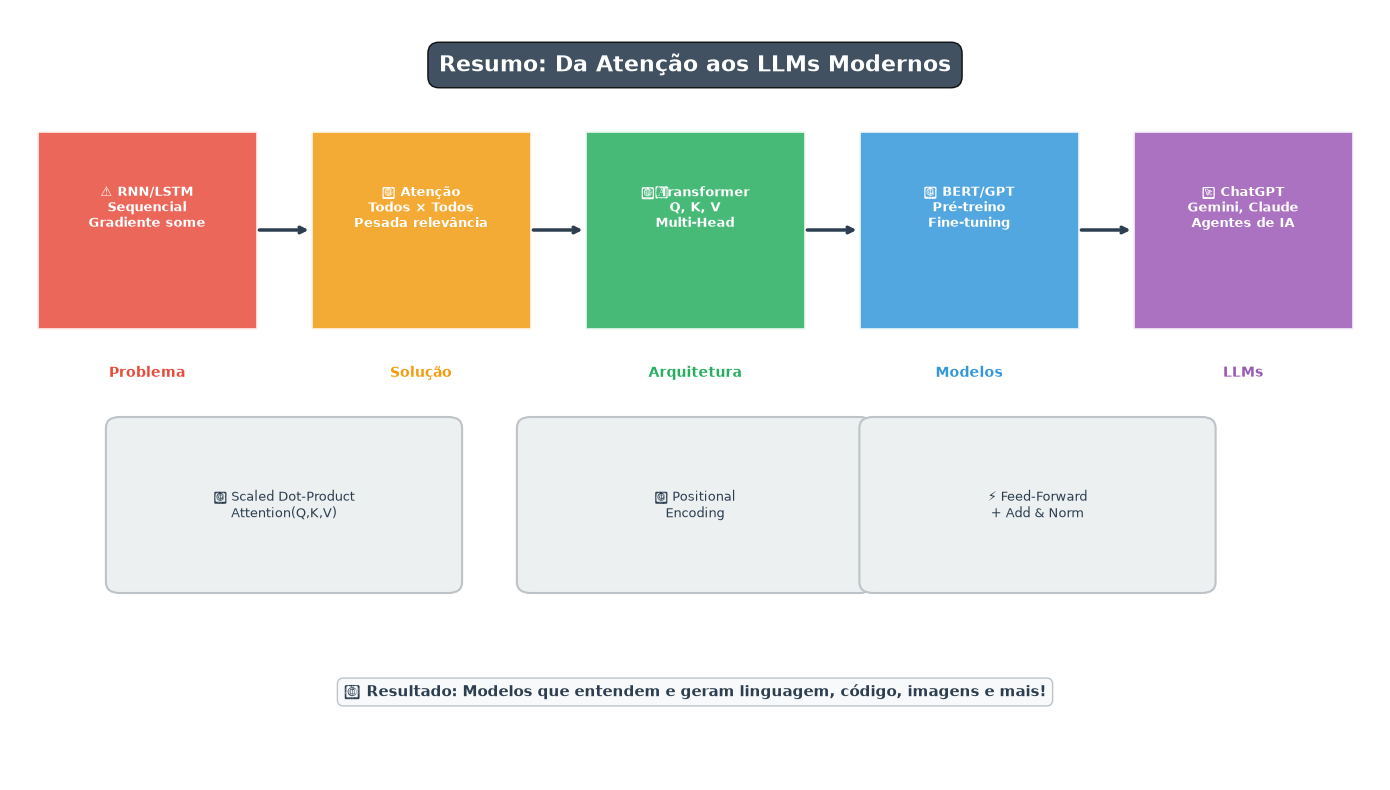


🏆 RESUMO FINAL:
✅ RNNs: sequenciais, esquecimento em longas sequências
✅ Atenção: todas as palavras se comunicam diretamente
✅ Q, K, V: mecanismo de busca por relevância
✅ Multi-Head: múltiplos tipos de relações em paralelo
✅ Positional Encoding: injeta informação de posição
✅ Transformer: blocos empilhados, totalmente paralelo
✅ LLMs: escala + dados + RLHF = inteligência emergente
✅ Aplicações: NLP, visão, código, agentes, multimodal


In [15]:
import matplotlib.patches as patches

# Diagrama visual resumindo a jornada
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

# Título
ax.text(5, 6.5, 'Resumo: Da Atenção aos LLMs Modernos',
        ha='center', va='center', fontsize=16, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#2c3e50', alpha=0.9),
        color='white')

# Blocos da jornada
etapas = [
    (1,   5, '⚠️ RNN/LSTM\nSequencial\nGradiente some', '#e74c3c', 'Problema'),
    (3,   5, '💡 Atenção\nTodos × Todos\nPesada relevância', '#f39c12', 'Solução'),
    (5,   5, '🏗️ Transformer\nQ, K, V\nMulti-Head', '#27ae60', 'Arquitetura'),
    (7,   5, '📦 BERT/GPT\nPré-treino\nFine-tuning', '#3498db', 'Modelos'),
    (9,   5, '🚀 ChatGPT\nGemini, Claude\nAgentes de IA', '#9b59b6', 'LLMs'),
]

for x, y, texto, cor, label in etapas:
    ax.add_patch(plt.Rectangle((x-0.8, y-0.9), 1.6, 1.8,
                                facecolor=cor, alpha=0.85, edgecolor='white', linewidth=2))
    ax.text(x, y+0.2, texto, ha='center', va='center', fontsize=9,
            color='white', fontweight='bold')
    ax.text(x, y-1.3, label, ha='center', va='center', fontsize=10,
            color=cor, fontweight='bold')

# Setas de conexão
for x in [1.8, 3.8, 5.8, 7.8]:
    ax.annotate('', xy=(x+0.4, 5), xytext=(x, 5),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2.5))

# Componentes chave
componentes = [
    (2, 2.5, '📐 Scaled Dot-Product\nAttention(Q,K,V)'),
    (5, 2.5, '🔀 Positional\nEncoding'),
    (7.5, 2.5, '⚡ Feed-Forward\n+ Add & Norm'),
]

for x, y, texto in componentes:
    ax.add_patch(patches.FancyBboxPatch((x-1.2, y-0.7), 2.4, 1.4,
                                     boxstyle='round,pad=0.1',
                                     facecolor='#ecf0f1', edgecolor='#bdc3c7', linewidth=1.5))
    ax.text(x, y, texto, ha='center', va='center', fontsize=9, color='#2c3e50')

ax.text(5, 0.8, '🎯 Resultado: Modelos que entendem e geram linguagem, código, imagens e mais!',
        ha='center', va='center', fontsize=11, fontweight='bold', color='#2c3e50',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='#bdc3c7'))

plt.tight_layout()
plt.show()

print('\n🏆 RESUMO FINAL:')
print('=' * 55)
print('✅ RNNs: sequenciais, esquecimento em longas sequências')
print('✅ Atenção: todas as palavras se comunicam diretamente')
print('✅ Q, K, V: mecanismo de busca por relevância')
print('✅ Multi-Head: múltiplos tipos de relações em paralelo')
print('✅ Positional Encoding: injeta informação de posição')
print('✅ Transformer: blocos empilhados, totalmente paralelo')
print('✅ LLMs: escala + dados + RLHF = inteligência emergente')
print('✅ Aplicações: NLP, visão, código, agentes, multimodal')